In [ ]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import ee
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

In [ ]:
chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
    .filterDate('1981-01-01', '2017-01-01')     

In [ ]:
count = chirps.size();

In [ ]:
aoi = ee.Geometry.Point(-75.60852, 6.284253)

In [ ]:
def new_list(image): 
    value = ee.Image(image).reduceRegion(ee.Reducer.first(), aoi).get('precipitation')
    year = ee.Number(ee.Image(image).date().format().slice(0,4))
    doy = ee.Number(ee.Image(image).date().getRelative('day', 'year')).add(1)
    myList = ee.List([]).add(year).add(doy).add(value)
    return myList

In [ ]:
precipit_list = chirps.toList(count).map(new_list);

In [ ]:
myFeatures = ee.FeatureCollection(precipit_list.map(ee.List(precipit_list)))

In [ ]:
 datos=myFeatures.get(2)

In [76]:
type(datos)

ee.computedobject.ComputedObject

TypeError: ignored

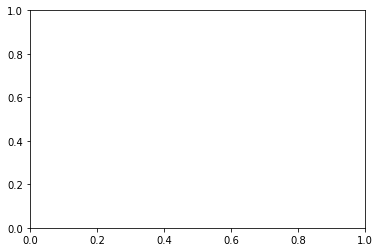

In [75]:
plt.plot(datos)

In [5]:
ruta_in= "G:/Mi unidad/INVESTIGACION/Bases de datos/"
file= open(ruta_in+'Lluvia_EPM_VdeA.bin', 'rb')
arreglo=pickle.load(file)
file.close()
df=pd.DataFrame(arreglo)
df.tail(5)

FileNotFoundError: ignored

In [ ]:
from google.colab import drive
drive.mount('/content/drive')